# Cross-plane connectivity: why some face matches need more than `lb`/`ub`

When `plot3d.connectivity.connectivity()` matches two block faces, it has
to record **how their points line up** -- not just that they touch. Most
of the time `lb`/`ub` alone says enough. Sometimes it doesn't, and that's
what this notebook is about.

This is a side quest from [`Plot3D_Flatten.ipynb`](Plot3D_Flatten.ipynb) --
you don't need it to flatten a mesh, only if you want to understand exactly
what `permutation_index`/`permutation_matrix` mean in a `connectivity.json`
file, or why a face match needs one at all. For the full historical
root-cause writeup (a real 10,469-face case study), see
[`docs/notes/cross_plane_pair.md`](../docs/notes/cross_plane_pair.md) and
[`docs/notes/connectivity.rst`](../docs/notes/connectivity.rst).


## Install

Requires **plot3d 1.10.0+**:


In [1]:
!pip install "plot3d>=1.10.0"


zsh:1: command not found: pip


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from plot3d.connectivity import PERMUTATION_MATRICES


### The diagonal (`lb`/`ub`) convention

Every matched face is stored as two node-index corners, `lb = [i, j, k]`
(lower bound) and `ub = [i, j, k]` (upper bound). One axis is always
constant (`lb[axis] == ub[axis]`), and that axis + value tells you which
of the block's 6 faces this is:

- `i` the same at both ends, equal to `0` -> `I=1`; equal to `IMAX-1` ->
  `I=IMAX`.
- `j` the same -> `J=1` or `J=JMAX`.
- `k` the same -> `K=1` or `K=KMAX`.

Block1's `lb`/`ub` is always ascending. Block2's isn't: it can have
`lb > ub` on a varying axis, and that's how a "flipped" face is recorded
-- no separate flag needed.

Two blocks side by side, block 0's right face (`I=IMAX`) touching block
1's left face (`I=1`):

```
  +--------+--------+
  |        |        |
  | BLOCK0 | BLOCK1 |
  |        |        |
  +--------+--------+
           ^
     shared face
  block0: I=IMAX      block1: I=1
```

Both sides describe the same physical plane of nodes, just from each
block's own point of view.


### `face_matches` records

```json
{
  "block1": {"block_index": 0, "lb": [i, j, k], "ub": [i, j, k]},
  "block2": {"block_index": 1, "lb": [i, j, k], "ub": [i, j, k]},
  "permutation_index": -1,
  "permutation_matrix": [[1, 0], [0, 1]]
}
```

`permutation_index` here is `-1` -- a "not needed" flag for this simple,
same-plane match (block2's `lb`/`ub` direction already says everything
there is to say). It can also be `4`, `5`, `6`, or `7` for a trickier
match where the two faces sit on different planes -- that's the
**cross-plane** case, and the rest of this notebook is about exactly what
that means.


### `permutation_index` and `permutation_matrix`

When two faces match, their local `(u, v)` directions might not line up:
either one could be flipped, or `u`/`v` could be swapped entirely (this
happens when the two faces sit on **different** axes -- e.g. one varies
in `(j, k)`, the other in `(i, k)`). Count it up: `2 x 2 x 2 = 8` possible
orientations. `plot3d.connectivity.PERMUTATION_MATRICES` is the fixed
list of the 8 small matrices that describe them:


In [3]:
# 0: identity, 1: u reversed, 2: v reversed, 3: both reversed,
# 4: swapped, 5: swap + u reversed, 6: swap + v reversed, 7: swap + both reversed
for i, m in enumerate(PERMUTATION_MATRICES):
    print(i, m.tolist())

0 [[1, 0], [0, 1]]
1 [[-1, 0], [0, 1]]
2 [[1, 0], [0, -1]]
3 [[-1, 0], [0, -1]]
4 [[0, 1], [1, 0]]
5 [[0, -1], [1, 0]]
6 [[0, 1], [-1, 0]]
7 [[0, -1], [-1, 0]]


`write_connectivity_json` always writes both fields:

- `permutation_index`: `-1` for in-plane matches (0-3), because the
  direction is already encoded in block2's `lb`/`ub`. The real `4-7`
  value is used for cross-plane matches, since `lb`/`ub` can't represent
  an axis swap.
- `permutation_matrix`: always the actual 2x2 matrix.

The whole idea behind the permutation matrix is to provide a map:
**Face B * permutation matrix = Face A**.


Same idea, pictured: same constant axis (top) -> 4 orientations, all
covered by lb/ub direction flips. Different constant axis, a *cross-plane*
pair (bottom) -> 8 orientations, only 4 reachable by lb/ub alone -- why the
`swapped` bit exists. Right panel: a cross-plane pair's faces walk points
in different-length strips, so a naive lb/ub traversal desyncs.


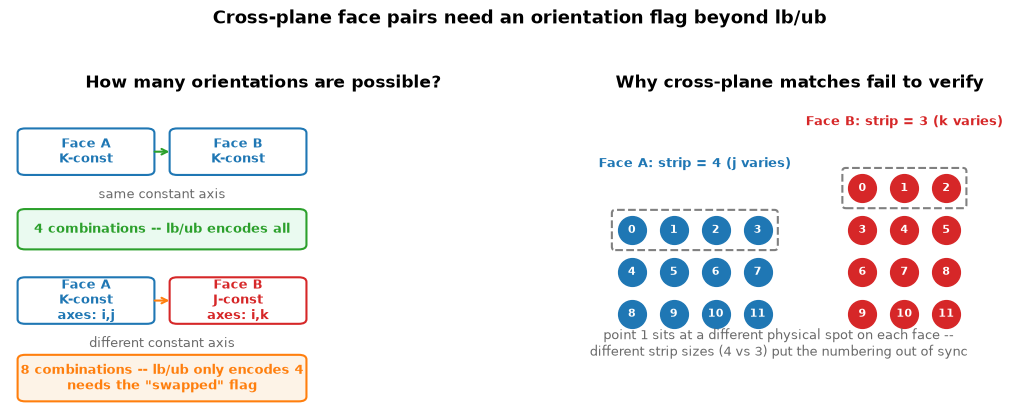

In [4]:
FACE_A, FACE_B, MATCH, NEED_SWAP = 'tab:blue', 'tab:red', 'tab:green', 'tab:orange'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Panel A: same axis (4 combos) vs cross-plane (8 combos) ---
ax = axes[0]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_title('How many orientations are possible?', fontsize=12, fontweight='bold')


def box(x, y, w, h, text, color):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle='round,pad=0.15',
        linewidth=1.5, edgecolor=color, facecolor='none'))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center',
            fontsize=9, color=color, fontweight='bold')


box(0.3, 7.6, 2.4, 1.2, 'Face A\nK-const', FACE_A)
box(3.3, 7.6, 2.4, 1.2, 'Face B\nK-const', FACE_A)
ax.annotate('', xy=(3.2, 8.2), xytext=(2.8, 8.2),
            arrowprops=dict(arrowstyle='->', color=MATCH, lw=1.5))
ax.text(3.0, 6.7, 'same constant axis', ha='center', fontsize=9, color='dimgray')
ax.add_patch(mpatches.FancyBboxPatch(
    (0.3, 5.2), 5.4, 1.0, boxstyle='round,pad=0.15',
    linewidth=1.5, edgecolor=MATCH, facecolor='#eafaf0'))
ax.text(3.0, 5.7, '4 combinations -- lb/ub encodes all',
        ha='center', va='center', fontsize=9, color=MATCH, fontweight='bold')

box(0.3, 2.8, 2.4, 1.2, 'Face A\nK-const\naxes: i,j', FACE_A)
box(3.3, 2.8, 2.4, 1.2, 'Face B\nJ-const\naxes: i,k', FACE_B)
ax.annotate('', xy=(3.2, 3.4), xytext=(2.8, 3.4),
            arrowprops=dict(arrowstyle='->', color=NEED_SWAP, lw=1.5))
ax.text(3.0, 1.9, 'different constant axis', ha='center', fontsize=9, color='dimgray')
ax.add_patch(mpatches.FancyBboxPatch(
    (0.3, 0.3), 5.4, 1.2, boxstyle='round,pad=0.15',
    linewidth=1.5, edgecolor=NEED_SWAP, facecolor='#fdf3e7'))
ax.text(3.0, 0.9,
        '8 combinations -- lb/ub only encodes 4\nneeds the "swapped" flag',
        ha='center', va='center', fontsize=9, color=NEED_SWAP, fontweight='bold')

# --- Panel B: strip-size mismatch ---
ax = axes[1]
ax.set_title('Why cross-plane matches fail to verify', fontsize=12, fontweight='bold')


def draw_grid(ax, ni, nj, color, x_off):
    n = 0
    for i in range(ni):
        for j in range(nj):
            x, y = x_off + j, ni - 1 - i
            ax.plot(x, y, 'o', color=color, markersize=20, zorder=3)
            ax.text(x, y, str(n), color='white', fontsize=8, ha='center',
                    va='center', fontweight='bold', zorder=4)
            n += 1
    rect = mpatches.FancyBboxPatch(
        (x_off - 0.4, ni - 1 - 0.4), nj - 0.2, 0.8,
        boxstyle='round,pad=0.08', linewidth=1.5,
        edgecolor='gray', facecolor='none', linestyle='--')
    ax.add_patch(rect)


ax.axis('off')
ni_a, nj_a = 3, 4  # Face A: strip of 4 (j varies)
ni_b, nk_b = 4, 3  # Face B: strip of 3 (k varies)
draw_grid(ax, ni_a, nj_a, FACE_A, x_off=0)
draw_grid(ax, ni_b, nk_b, FACE_B, x_off=nj_a + 1.5)

ax.text(nj_a / 2 - 0.5, ni_a + 0.5, 'Face A: strip = 4 (j varies)',
        ha='center', fontsize=9, color=FACE_A, fontweight='bold')
ax.text(nj_a + 1.5 + nk_b / 2 - 0.5, max(ni_a, ni_b) + 0.5,
        'Face B: strip = 3 (k varies)', ha='center', fontsize=9, color=FACE_B, fontweight='bold')

ax.text((nj_a + 1.5 + nk_b) / 2 - 0.75, -1.0,
        'point 1 sits at a different physical spot on each face --\n'
        'different strip sizes (4 vs 3) put the numbering out of sync',
        ha='center', fontsize=9, color='dimgray')

ax.set_xlim(-1, nj_a + 1.5 + nk_b + 0.5)
ax.set_ylim(-2.2, max(ni_a, ni_b) + 1.2)
ax.set_aspect('equal')

fig.suptitle('Cross-plane face pairs need an orientation flag beyond lb/ub',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## Where to go next

- Building a graph from a mesh, with or without any of this?
  [`Plot3D_Flatten.ipynb`](Plot3D_Flatten.ipynb) -- this notebook's
  content isn't a prerequisite for it.
- The full root-cause story, with a real 10,469-face case study from a
  production turbine mesh: [`docs/notes/cross_plane_pair.md`](../docs/notes/cross_plane_pair.md).
- The permutation-matrix bit encoding and the directed-diagonal export
  convention: [`docs/notes/connectivity.rst`](../docs/notes/connectivity.rst).
